In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

In [4]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

K-Fold Validation

In [5]:
n_fold = 10

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
)

cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)


In [6]:
#Testing on unseen data
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Airplanes': 0, 'Drones': 1, 'Explosion': 2, 'Gunshots': 3, 'Helicopter': 4, 'Land_Vehicles': 5, 'shortened_unlabeled': 6}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6000
                     precision    recall  f1-score   support

          Airplanes       0.92      0.76      0.83        75
             Drones       0.95      0.27      0.42        75
          Explosion       0.57      0.77      0.66        75
           Gunshots       0.80      0.44      0.57        75
         Helicopter       0.54      0.57      0.55        75
      Land_Vehicles       0.38      0.48      0.43        75
shortened_unlabeled       0.54      0.91      0.68        75

           accuracy                           0.60       525
          macro avg       0.67      0.60      0.59       525
       weighted avg       0.67      0.60      0.59       525



Visualize

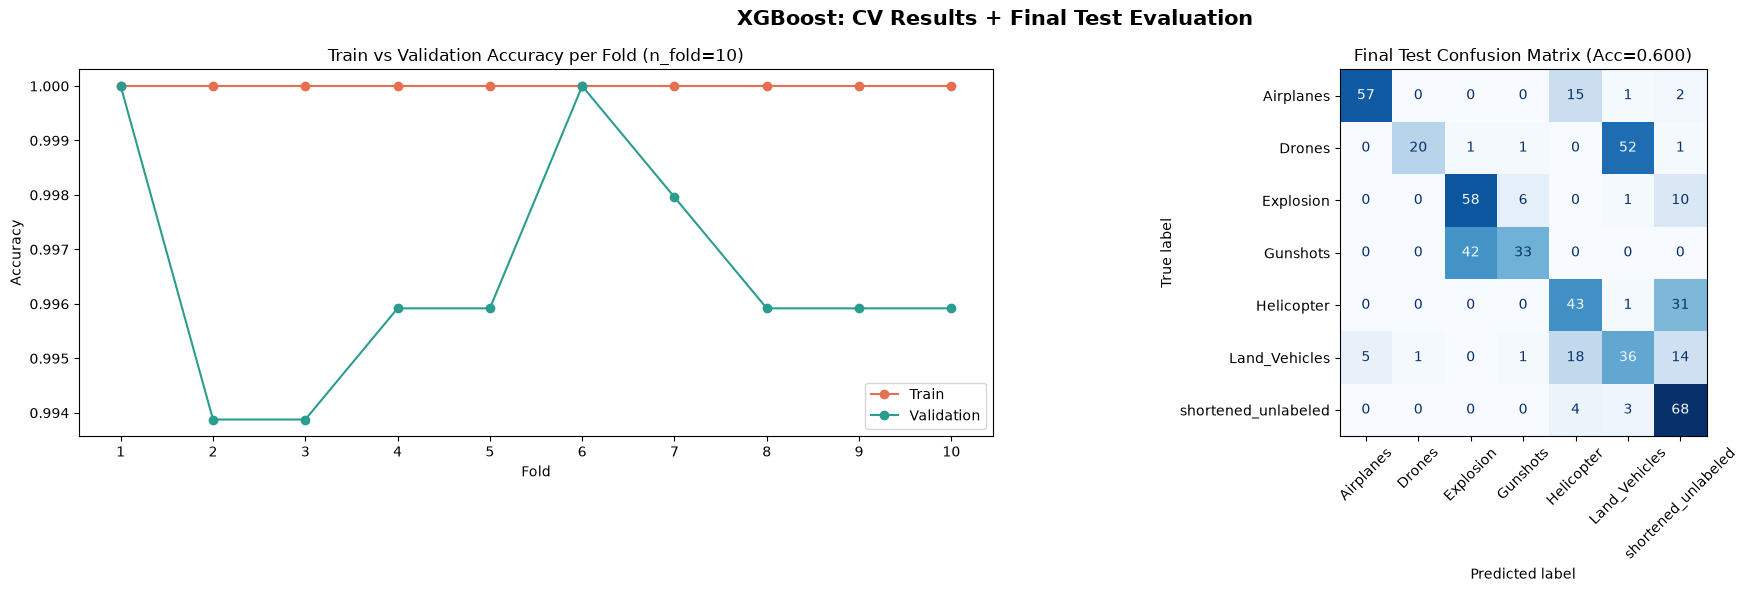

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("XGBoost: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# (a) Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, n_fold + 1)
ax.plot(folds, cv_results["train_score"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_score"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Train vs Validation Accuracy per Fold (n_fold={n_fold})")
ax.legend()

# (b) Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")

plt.tight_layout()
plt.show()

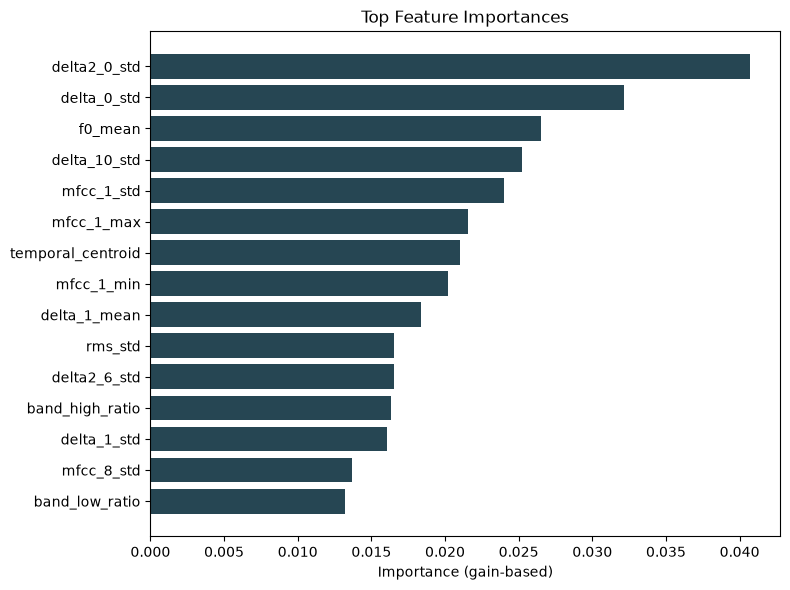

In [8]:
feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Parameter Tuning

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

n_classes = len(np.unique(y_train))

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# XGBoost has no class_weight param — use sample_weight instead to handle imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
random_search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = XGBClassifier(
    n_estimators=200,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42
)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best CV f1_macro score: 0.9946933798769461

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.6210
                     precision    recall  f1-score   support

          Airplanes       0.92      0.75      0.82        75
             Drones       0.89      0.33      0.49        75
          Explosion       0.58      0.76      0.66        75
           Gunshots       0.77      0.45      0.57        75
         Helicopter       0.61      0.61      0.61        75
      Land_Vehicles       0.44      0.52      0.48        75
shortened_unlabeled       0.53      0.92      0.67        75

           accuracy                           0.62       525
          macro avg       0.68      0.62      0.61       525
       weighted avg       0.68      0.62      0.61       525



Re-Evaluating w/ Additional Features

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from pathlib import Path
import pandas as pd

train_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v2\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

X_train = train_df.drop(columns=["filepath", "label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["filepath", "label"])
y_test = test_df["label"]

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

K-Fold Validation

In [2]:
n_fold = 10

clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
)

cv = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)
#Testing on unseen data
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

class_names = {'Airplanes': 0, 'Drones': 1, 'Explosion': 2, 'Gunshots': 3, 'Helicopter': 4, 'Land_Vehicles': 5, 'shortened_unlabeled': 6}
target_names = [name for name, idx in sorted(class_names.items(), key=lambda x: x[1])]

print("\n=== Final Held-Out Test ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names))


=== Final Held-Out Test ===
Test Accuracy: 0.6324
                     precision    recall  f1-score   support

          Airplanes       0.93      0.76      0.84        75
             Drones       0.94      0.39      0.55        75
          Explosion       0.57      0.77      0.66        75
           Gunshots       0.80      0.48      0.60        75
         Helicopter       0.57      0.60      0.58        75
      Land_Vehicles       0.47      0.49      0.48        75
shortened_unlabeled       0.54      0.93      0.69        75

           accuracy                           0.63       525
          macro avg       0.69      0.63      0.63       525
       weighted avg       0.69      0.63      0.63       525



Visualize

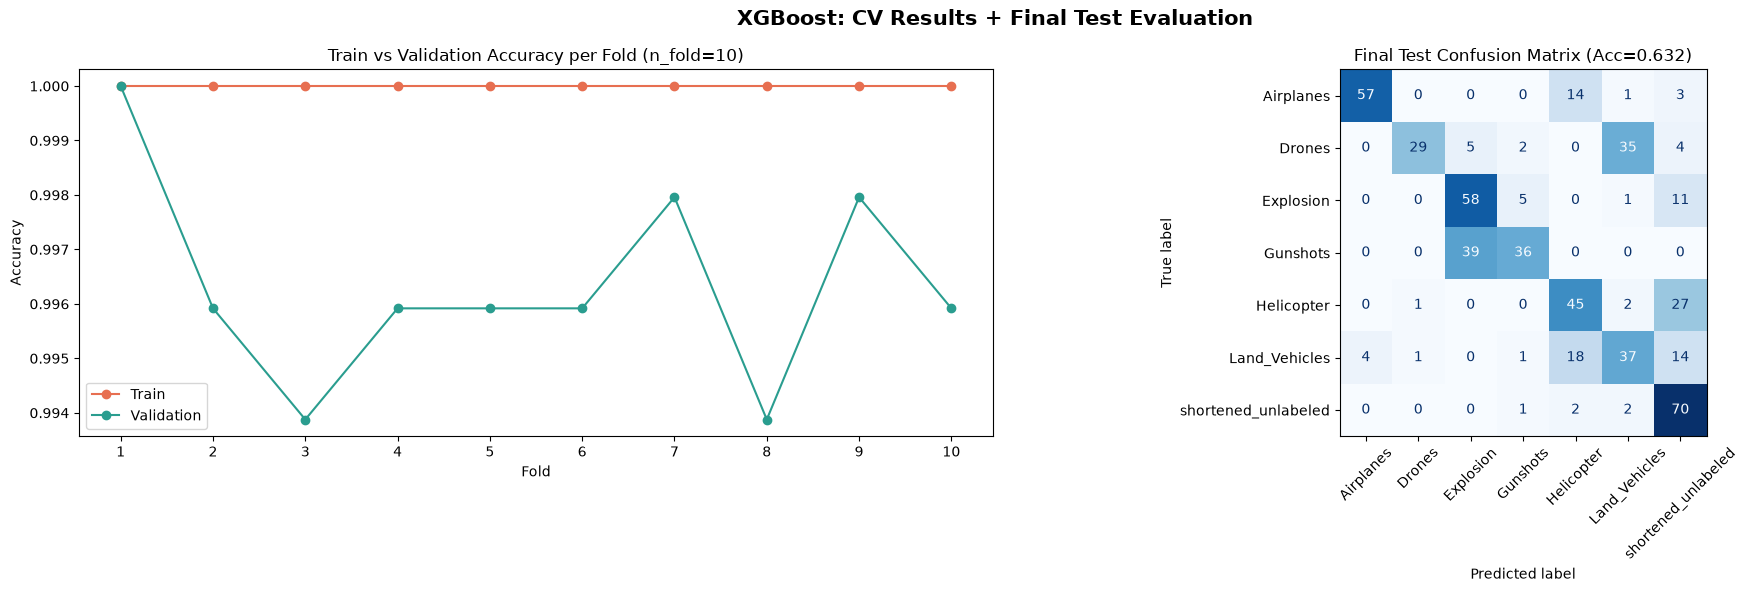

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("XGBoost: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

# (a) Train vs validation accuracy per fold (overfitting check)
ax = axes[0]
folds = np.arange(1, n_fold + 1)
ax.plot(folds, cv_results["train_score"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_score"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title(f"Train vs Validation Accuracy per Fold (n_fold={n_fold})")
ax.legend()

# (b) Confusion matrix on final held-out test set
ax = axes[1]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"Final Test Confusion Matrix (Acc={test_acc:.3f})")

plt.tight_layout()
plt.show()

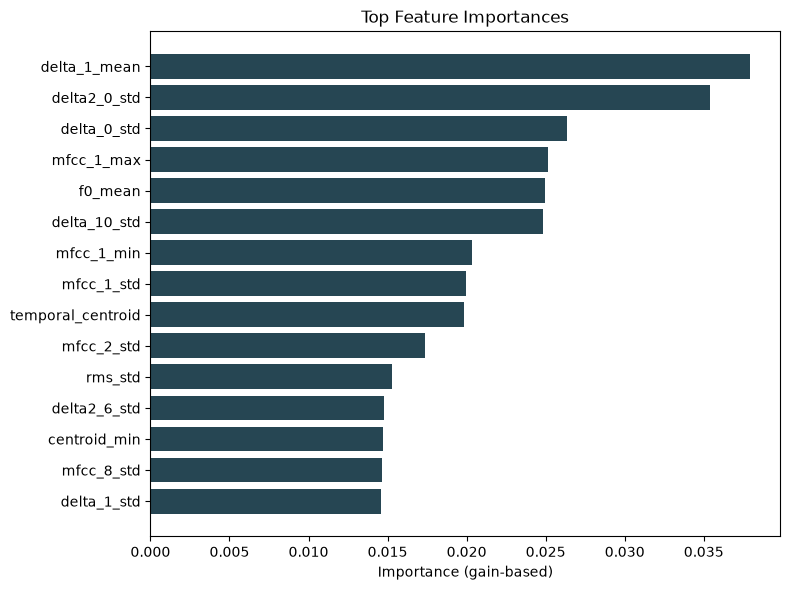

In [4]:
feature_names = X_train.columns
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top Feature Importances")
plt.tight_layout()
plt.show()

Param Tuning

In [5]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np

n_classes = len(np.unique(y_train))

param_dist = {
    "n_estimators": [300, 400, 500, 600, 700],
    "max_depth": [6, 7, 8, 15, 20],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# -----------------------------
# 2. Run randomized search
#    scoring="f1_macro" weighs weak classes (like Gunshots) equally,
#    instead of letting accuracy hide behind the strong classes
# -----------------------------
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# XGBoost has no class_weight param — use sample_weight instead to handle imbalance
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
random_search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", random_search.best_params_)
print("Best CV f1_macro score:", random_search.best_score_)

clf_tuned = random_search.best_estimator_

# -----------------------------
# 3. Compare tuned vs default model on the SAME untouched test set
# -----------------------------
clf_default = XGBClassifier(
    n_estimators=200,
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    random_state=42
)
clf_default.fit(X_train, y_train)

for name, model in [("Default", clf_default), ("Tuned", clf_tuned)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} Model — Final Held-Out Test ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred)
    recall_per_class = cm.diagonal() / cm.sum(axis=1)
    print(f"Per-class recall ({name}):")
    for cname, r in zip(target_names, recall_per_class):
        print(f"  {cname:25s}: {r:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best params: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV f1_macro score: 0.9971411389955394

=== Default Model — Final Held-Out Test ===
Test Accuracy: 0.6210
                     precision    recall  f1-score   support

          Airplanes       0.92      0.77      0.84        75
             Drones       0.90      0.36      0.51        75
          Explosion       0.59      0.76      0.66        75
           Gunshots       0.71      0.49      0.58        75
         Helicopter       0.55      0.53      0.54        75
      Land_Vehicles       0.50      0.51      0.50        75
shortened_unlabeled       0.51      0.92      0.66        75

           accuracy                           0.62       525
          macro avg       0.67      0.62      0.61       525
       weighted avg       0.67      0.62      0.61       525

Pe